# Decision trees (DTs)

## Explanation

**General information**

- Decision trees belong to the group of supervised machine learning algorithms
- The algorithm can be used for both classification and regression tasks
- The general class of algorithms is often summarized as under the term "Classification and Regression Tree Algorithm" (in short "CART")
- Tree-based methods involve **segmenting the predictor** space in regions
- The set of splitting rules used to segment can be summarized in a tree (also known as decision tree)



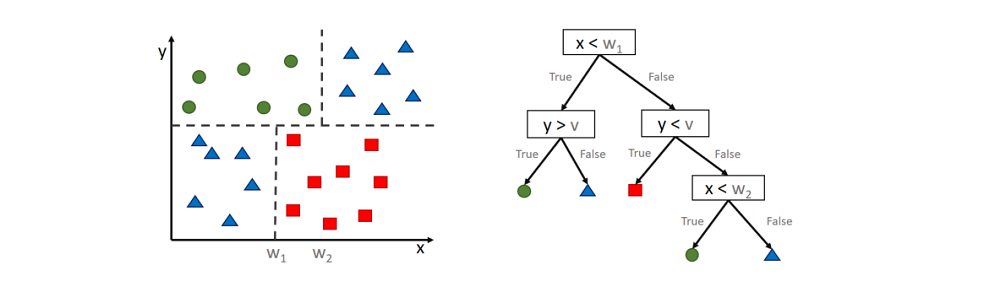

Underlying mechanic for creating a decision tree is **recursive binary splitting**:
- At each step of tree-bulding process, the best split is made at that particular step.
- Nodes are therefore ordered (top - down) by importance of the features.
- The algorithm does not foresee all possible splits in later steps.

**Recursive binary splitting**

Various methods exist for determining the next best splitting criterion in each case
- Regression -> Residual Sum of Squares (RSS)
- Classifcation -> Gini Index or Entropy

Methods are used to measure the impurity or information content in a particular node of the decision tree.

**Entropy**

Measures the uncertainty about how well a particular node can predict the classes or labels of the data points.

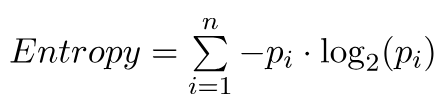

- S represents the data set used to calculate the entropy
- n represents the classes in set S
- p(i) represents the number of data points belonging to class n in relation to the total number of data points in set S

Entropy values can be between 0 and 1 (if you have two classes):
- Entropy = 0 -> all samples in data set S belong to one class (Classification is very pure)
- Entropy = 1 -> half of the samples are assigned to one class and the other half to another class (Classification is very impure)

The entropy is calculated for all existing features in the data set.

The information gain represents the difference in entropy before and after a split based on a specific attribute. The attribute with the highest information gain produces the best split as it best classifies the training data according to its target classification.

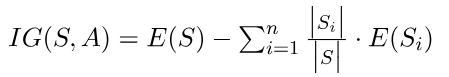

## Code

### Import relevant modules

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, validation_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

### Load Titanic CSV into a pandas DataFrame

In [16]:
csv_path = Path("titanic.csv")
df = pd.read_csv(csv_path)

# Handle column naming differences across Titanic CSV variants.
target_col = next((c for c in ["Survived", "survived", "2urvived"] if c in df.columns), None)
sibsp_col = next((c for c in ["SibSp", "sibsp"] if c in df.columns), None)

if target_col is None or sibsp_col is None:
    raise ValueError(f"Unexpected columns. Found: {df.columns.tolist()}")

feature_cols = ["Pclass", "Sex", "Age", sibsp_col, "Parch", "Fare", "Embarked"]
work_df = df[feature_cols + [target_col]].copy()

pd.set_option("display.max_columns", None)
print("Columns in use:", feature_cols + [target_col])
work_df.head()

Columns in use: ['Pclass', 'Sex', 'Age', 'sibsp', 'Parch', 'Fare', 'Embarked', '2urvived']


,Pclass,Sex,Age,sibsp,Parch,Fare,Embarked,2urvived
0,3,0,22.0,1,0,7.2500,2.0,0
1,1,1,38.0,1,0,71.2833,0.0,1
2,3,1,26.0,0,0,7.9250,2.0,1
3,1,1,35.0,1,0,53.1000,2.0,1
4,3,0,35.0,0,0,8.0500,2.0,0


### Examine the dataset

In [17]:
# Checking data types
df.dtypes

Passengerid      int64
Age            float64
Fare           float64
Sex              int64
sibsp            int64
zero             int64
zero.1           int64
zero.2           int64
zero.3           int64
zero.4           int64
zero.5           int64
zero.6           int64
Parch            int64
zero.7           int64
zero.8           int64
zero.9           int64
zero.10          int64
zero.11          int64
zero.12          int64
zero.13          int64
zero.14          int64
Pclass           int64
zero.15          int64
zero.16          int64
Embarked       float64
zero.17          int64
zero.18          int64
2urvived         int64
dtype: object

In [18]:
# Checking NaN
df.isna().sum()

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64

In [19]:
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,zero.6,Parch,zero.7,zero.8,zero.9,zero.10,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.385027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.865560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


### Visualization

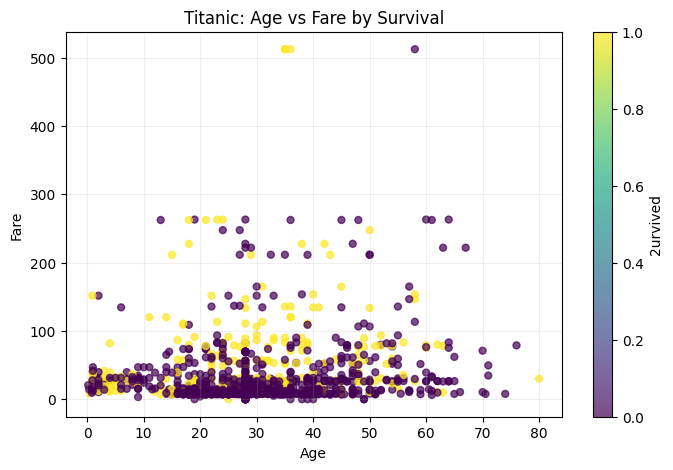

In [20]:
# Plot relationship between age and fare with survival as color
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    work_df["Age"],
    work_df["Fare"],
    c=work_df[target_col],
    cmap="viridis",
    alpha=0.7,
    s=25
)
plt.colorbar(scatter, label=target_col)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Titanic: Age vs Fare by Survival")
plt.grid(alpha=0.2)
plt.show()

### Modeling

#### Splitting data

In [21]:
# Specify features (X) and label (y)
X = work_df[feature_cols]
y = work_df[target_col]

# Split data (20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (1047, 7) (1047,)
Testing set shape: (262, 7) (262,)


#### DT by sklearn

In [22]:
# Hyperparameters
splitting_criterion = "gini"
max_depth = 4
min_samples_split = 10
min_samples_leaf = 5

# Train decision tree
dt_model = DecisionTreeClassifier(
    criterion=splitting_criterion,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    random_state=42
)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

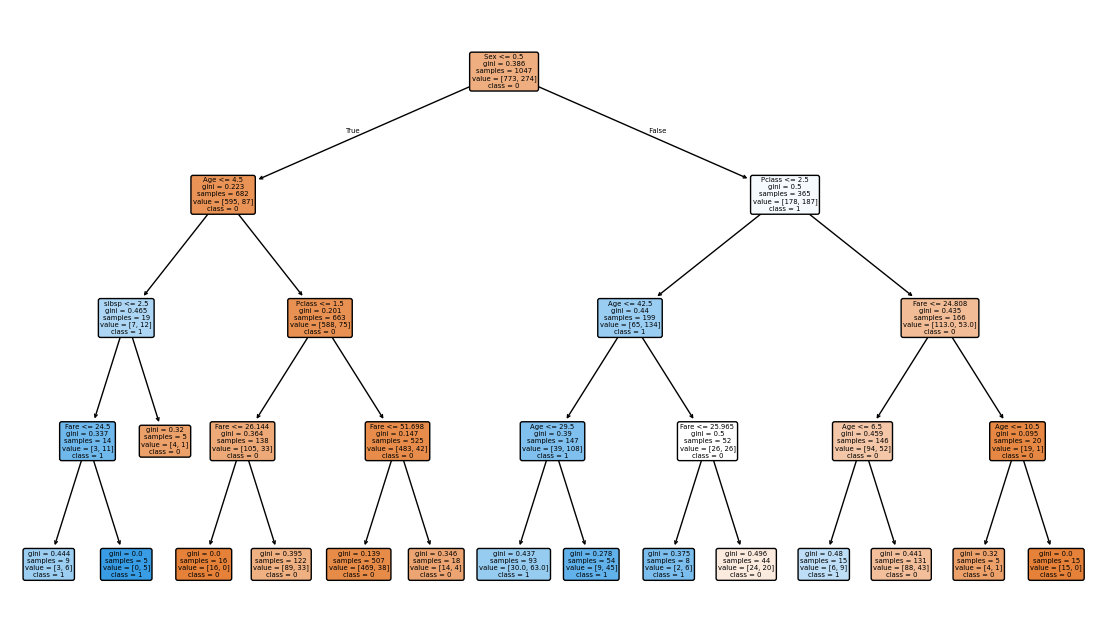

In [23]:
# Plot trained decision tree
fig = plt.figure(figsize=(14, 8))
_ = tree.plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True
 )
plt.show()

#### Evaluation

Accuracy: 0.7595
              precision    recall  f1-score   support

           0     0.8075    0.8866    0.8452       194
           1     0.5510    0.3971    0.4615        68

    accuracy                         0.7595       262
   macro avg     0.6793    0.6418    0.6534       262
weighted avg     0.7409    0.7595    0.7456       262



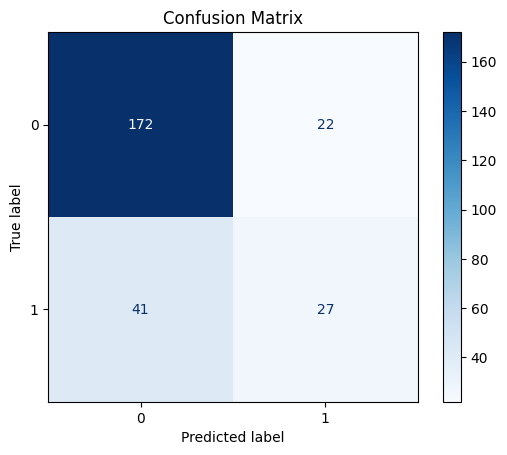

In [24]:
# Evaluation on test set
y_predicted_test = dt_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_predicted_test), 4))
print(classification_report(y_test, y_predicted_test, digits=4))

cm = confusion_matrix(y_test, y_predicted_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

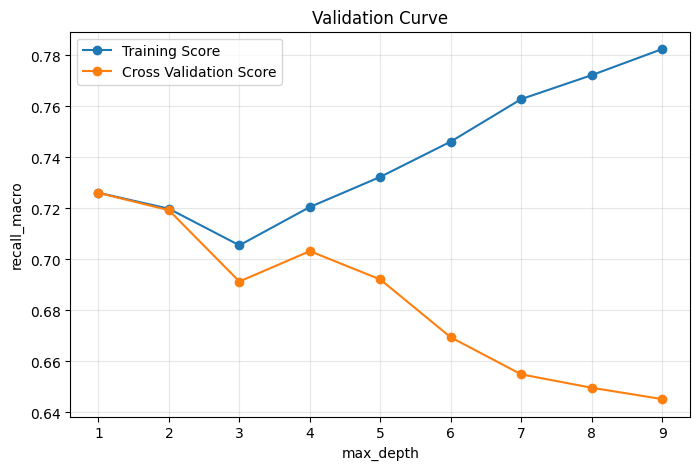

In [25]:
# Cross validation curve for max_depth
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_range = range(1, 10)

train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(
        criterion=splitting_criterion,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    ),
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=cv_splitter,
    scoring="recall_macro"
 )

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean, marker="o", label="Training Score")
plt.plot(param_range, val_mean, marker="o", label="Cross Validation Score")
plt.xlabel("max_depth")
plt.ylabel("recall_macro")
plt.title("Validation Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Advantages**
- Good explicability
- Possibility of graphical representation -> no black box problem

**Disadvantages**
- DTs tend to be non-robust -> small changes in the data can cause a large change in the final estimated tree
- DTs are not able to grasp relationships between features (multicollinearity)